In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [13]:
nav["date"] = pd.to_datetime(nav["date"])


In [14]:
nav = nav.sort_values(["amfi_code", "date"])

In [15]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [16]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [10]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [17]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [18]:
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [22]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [23]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [24]:
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [25]:
nifty100 = nifty100.sort_values("date")

In [27]:
nifty100["bench_return"] = nifty100["close_value"].pct_change()


In [28]:
nifty100.head()

,date,index_name,close_value,bench_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [30]:
nav = nav.merge(
    nifty100[["date", "bench_return"]],
    on="date",
    how="left"
)

In [31]:
nav.head()

,amfi_code,date,nav,daily_return,bench_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [43]:
nav.to_csv("../data/processed/returns_completed.csv", index=False)

In [35]:
def calculate_cagr(df, years):
    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    return (end_nav / start_nav) ** (1 / years) - 1
cagr_results = []

for fund, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    result = {
        "amfi_code": fund
    }

    # 1 Year CAGR
    if len(group) >= 252:
        result["cagr_1y"] = calculate_cagr(group.tail(252), 1)

    # 3 Year CAGR
    if len(group) >= 756:
        result["cagr_3y"] = calculate_cagr(group.tail(756), 3)

    # Add result to list
    cagr_results.append(result)

# Create DataFrame
cagr_df = pd.DataFrame(cagr_results)

# View results
cagr_df.head()

,amfi_code,cagr_1y,cagr_3y
0,100016,-0.033055,-0.000316
1,100025,0.025018,0.046143
2,100033,0.477346,0.336292
3,101206,0.450939,0.325286
4,101207,-0.242421,-0.026965


In [44]:
cagr_df.to_csv("../data/processed/cagr_report.csv", index=False)


In [36]:
RF = 0.065

In [37]:
def sharpe_ratio(returns):
    
    returns = returns.dropna()

    excess_returns = returns - (RF / 252)

    return (
        excess_returns.mean()
        / returns.std()
    ) * np.sqrt(252)

In [38]:
sharpe_df = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(sharpe_ratio)
    .reset_index(name="sharpe_ratio")
)

In [39]:
sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [45]:
sharpe_df.to_csv("../data/processed/sharpe_values.csv", index=False)


In [40]:
def sortino_ratio(returns):
    
    returns = returns.dropna()

    excess_returns = returns - (RF / 252)

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    return (
        excess_returns.mean()
        / downside_std
    ) * np.sqrt(252)

In [41]:
sortino_df = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(sortino_ratio)
    .reset_index(name="sortino_ratio")
)

In [42]:
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [46]:
sortino_df.to_csv("../data/processed/sortino_values.csv", index=False)


In [47]:
from scipy.stats import linregress
import numpy as np

In [48]:
def calculate_alpha_beta(df):
    
    df = df.dropna(
        subset=["daily_return", "bench_return"]
    )

    if len(df) < 30:
        return pd.Series({
            "alpha": np.nan,
            "beta": np.nan
        })

    beta, alpha, r_value, p_value, std_err = linregress(
        df["bench_return"],
        df["daily_return"]
    )

    return pd.Series({
        "alpha": alpha * 252,
        "beta": beta
    })

In [51]:
aalpha_beta_df = (
    nav.groupby("amfi_code")[["daily_return", "bench_return"]]
       .apply(calculate_alpha_beta)
       .reset_index()
)

In [52]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [53]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [54]:
def max_drawdown(nav_series):
    
    running_max = nav_series.cummax()

    drawdown = (
        nav_series / running_max
    ) - 1

    return drawdown.min()

In [55]:
mdd_df = (
    nav.groupby("amfi_code")["nav"]
       .apply(max_drawdown)
       .reset_index(name="max_drawdown")
)

In [56]:
mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [57]:
mdd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [97]:
import numpy as np
import pandas as pd

tracking_errors = []

for fund in top5_funds:

    temp = nav[nav["amfi_code"] == fund].copy()

    temp = temp.dropna(
        subset=["daily_return", "bench_return"]
    )

    tracking_error = (
        (temp["daily_return"] - temp["bench_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_errors.append({
        "amfi_code": fund,
        "tracking_error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_errors)

tracking_error_df

,amfi_code,tracking_error
0,148567,0.189664
1,100033,0.228699
2,120505,0.231968
3,120843,0.206425
4,120504,0.191587


In [98]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

In [78]:
# Expense Ratio
expense_df = fund_master[
    ["amfi_code", "expense_ratio_pct"]
].copy()

# Merge all metrics
scorecard_df = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(sortino_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(mdd_df, on="amfi_code")
    .merge(expense_df, on="amfi_code")
)

# Create ranks
scorecard_df["return_rank"] = (
    scorecard_df["cagr_3y"]
    .rank(ascending=False)
)

scorecard_df["sharpe_rank"] = (
    scorecard_df["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard_df["alpha_rank"] = (
    scorecard_df["alpha"]
    .rank(ascending=False)
)

# Lower expense ratio is better
scorecard_df["expense_rank"] = (
    scorecard_df["expense_ratio_pct"]
    .rank(ascending=True)
)

# Lower drawdown magnitude is better
scorecard_df["drawdown_rank"] = (
    scorecard_df["max_drawdown"]
    .rank(ascending=False)
)

# Composite Score
scorecard_df["fund_score"] = (
      scorecard_df["return_rank"] * 0.30
    + scorecard_df["sharpe_rank"] * 0.25
    + scorecard_df["alpha_rank"] * 0.20
    + scorecard_df["expense_rank"] * 0.15
    + scorecard_df["drawdown_rank"] * 0.10
)

# Convert to 0-100 scale
scorecard_df["fund_score_100"] = (
    (
        scorecard_df["fund_score"].max()
        - scorecard_df["fund_score"]
    )
    /
    (
        scorecard_df["fund_score"].max()
        - scorecard_df["fund_score"].min()
    )
) * 100

# Best funds first
scorecard_df = scorecard_df.sort_values(
    "fund_score_100",
    ascending=False
)

# View Top 10 Funds
scorecard_df.head(10)

,amfi_code,cagr_1y,cagr_3y,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,fund_score_100
34,148567,0.145807,0.312786,1.448291,2.385644,0.269838,0.023684,-0.112657,1.46,4.0,1.0,7.0,23.0,8.0,7.100,100.000000
2,100033,0.477346,0.336292,1.093699,1.829134,0.271954,0.005104,-0.162172,1.38,2.0,7.0,6.0,17.0,20.0,8.100,96.488147
25,120505,0.303534,0.302065,1.180101,2.029353,0.292636,0.000549,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,8.100,96.488147
30,120843,0.284811,0.256619,1.306744,2.364320,0.273305,-0.022830,-0.129740,1.45,10.0,2.0,5.0,22.0,13.0,9.100,92.976295
24,120504,0.115007,0.283698,1.026524,1.805294,0.211948,0.016232,-0.125883,0.80,6.0,10.0,13.0,12.0,12.0,9.900,90.166813
16,119094,0.309182,0.360660,0.998231,1.703797,0.260767,-0.066265,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,10.200,89.113257
19,119551,0.488839,0.277274,1.208267,2.140267,0.232010,-0.031751,-0.150124,1.54,8.0,4.0,10.0,30.5,17.0,11.675,83.933275
3,101206,0.450939,0.325286,1.027213,1.799563,0.213998,0.021086,-0.112916,1.60,3.0,9.0,12.0,36.5,9.0,11.925,83.055312
21,119598,0.845322,0.278144,0.945308,1.675317,0.303370,-0.023196,-0.287060,1.43,7.0,14.0,1.0,21.0,36.0,12.550,80.860404
36,148569,0.444657,0.233171,1.234930,2.146914,0.282704,0.018134,-0.163967,1.60,13.0,3.0,4.0,36.5,21.0,13.025,79.192274


In [81]:
scorecard_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [82]:
top5_funds = scorecard_df.head(5)["amfi_code"].tolist()

top5_funds

[148567, 100033, 120505, 120843, 120504]

In [83]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_funds)
].copy()

In [84]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty50 = nifty50.sort_values("date")

In [85]:
top5_nav["normalized"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
    * 100
)

nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
    * 100
)

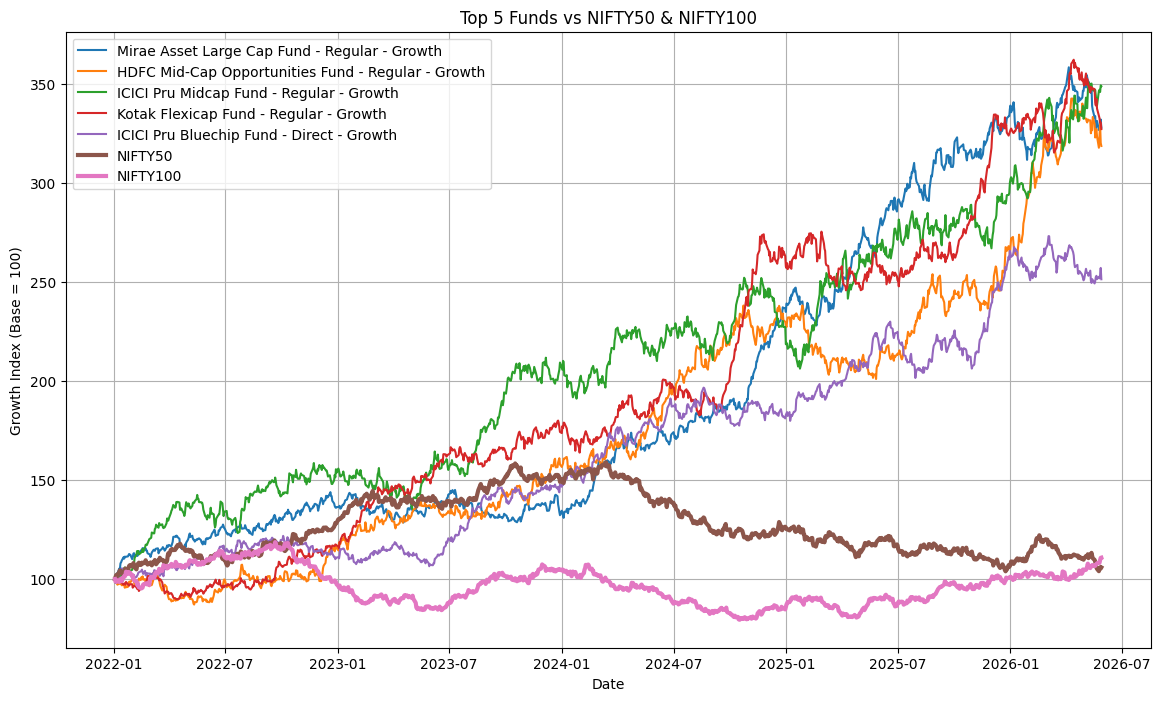

In [95]:
import matplotlib.pyplot as plt

fund_name_map = (
    fund_master[
        ["amfi_code", "scheme_name"]
    ]
    .set_index("amfi_code")["scheme_name"]
    .to_dict()
)

plt.figure(figsize=(14,8))

for fund in top5_funds:

    fund_data = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["normalized"],
        label=fund_name_map.get(fund, str(fund))
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    label="NIFTY50",
    linewidth=3
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    label="NIFTY100",
    linewidth=3
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("Growth Index (Base = 100)")
plt.legend()
plt.grid(True)

plt.savefig(
    "../charts/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [87]:
print("NIFTY50 Start:", nifty50["close_value"].iloc[0])
print("NIFTY50 End:", nifty50["close_value"].iloc[-1])

print("NIFTY100 Start:", nifty100["close_value"].iloc[0])
print("NIFTY100 End:", nifty100["close_value"].iloc[-1])

NIFTY50 Start: 17492.79
NIFTY50 End: 18517.65
NIFTY100 Start: 17778.24
NIFTY100 End: 19696.29


In [99]:
import os

os.listdir("../data/processed")

['alpha_beta.csv',
 'aum_by_fund_house_clean.csv',
 'benchmark_indices_clean.csv',
 'cagr_report.csv',
 'category_inflows_clean.csv',
 'fund_master_clean.csv',
 'fund_scorecard.csv',
 'industry_folio_count_clean.csv',
 'investor_transactions_clean.csv',
 'max_drawdown.csv',
 'monthly_sip_inflows_clean.csv',
 'nav_history_clean.csv',
 'portfolio_holdings_clean.csv',
 'returns_completed.csv',
 'scheme_performance_clean.csv',
 'sharpe_values.csv',
 'sortino_values.csv',
 'tracking_error.csv']